<a href="https://colab.research.google.com/github/smshozab/AG-AquaSense/blob/main/AAIn5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

This notebook combines outputs from all modalities using **Late Bayesian Fusion**.

### What this notebook does
- Loads:
  - P_text (Notebook 3)
  - P_sensor (Notebook 4)
  - P_cnn (simulated for now)
- Computes fusion:

  P_final = (w_cnn * P_cnn + w_text * P_text + w_sensor * P_sensor)

- Weights derived from modality Macro F1
- Runs ablation experiments:

  C1: Image only  
  C2: Image + Text  
  C3: Image + Sensor  
  C4: Full model  

### Key outputs
- Table II:
  - Macro F1 per configuration
  - Improvement over baseline
- McNemar statistical test
- Per-class metrics and confusion matrices

### Usage
- Central module for combining all predictions

### Note
- CNN is currently simulated; can be replaced later without code changes

HOW TO REPLACE SIMULATED CNN WITH REAL CNN LATER:

1. Keep the same 7 classes:
   - Bacterial Red Disease
   - Aeromoniasis
   - Bacterial Gill Disease
   - Saprolegniasis
   - Healthy Fish
   - Parasitic Diseases
   - White Tail Disease

2. Create a CSV with these columns:
   - fusion_id
   - true_label
   - P_cnn_Bacterial Red Disease
   - P_cnn_Aeromoniasis
   - P_cnn_Bacterial Gill Disease
   - P_cnn_Saprolegniasis
   - P_cnn_Healthy Fish
   - P_cnn_Parasitic Diseases
   - P_cnn_White Tail Disease

3. Save it over:
   /content/drive/MyDrive/aquasense/notebook5_outputs/p_cnn_simulated.csv

   OR change the load path in Cell 13.

4. Update macro_f1_cnn in Cell 15 using the real CNN validation macro F1 from Notebook 2.

5. Rerun Notebook 5 from Cell 13 onward.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from scipy.stats import chi2

In [13]:
from pathlib import Path
import numpy as np

BASE_DIR = Path("/content/drive/MyDrive/aquasense")

TEXT_PATH = BASE_DIR / "/content/p_text_predictions.csv"
TEXT_METRICS_PATH = BASE_DIR / "notebook3_outputs" / "fasttext_metrics_summary.csv"

SENSOR_PATH = BASE_DIR / "notebook4_outputs" / "p_sensor_predictions.csv"
SENSOR_METRICS_PATH = BASE_DIR / "notebook4_outputs" / "xgboost_metrics_summary.csv"

OUTPUT_DIR = BASE_DIR / "notebook5_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_SIMULATED_CNN = False
SIMULATED_CNN_PATH = "/content/p_cnn.csv"

DISEASE_CLASSES = [
    "Bacterial Red Disease",
    "Aeromoniasis",
    "Bacterial Gill Disease",
    "Saprolegniasis",
    "Healthy Fish",
    "Parasitic Diseases",
    "White Tail Disease"
]

SEED = 42
np.random.seed(SEED)

In [ ]:
def normalize_prob_matrix(prob_df, cols):
    arr = prob_df[cols].values.astype(float)
    row_sums = arr.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    arr = arr / row_sums
    out = prob_df.copy()
    out[cols] = arr
    return out


def get_pred_from_probs(df, prob_cols, class_prefix):
    arr = df[prob_cols].values
    pred_idx = np.argmax(arr, axis=1)
    classes = [c.replace(class_prefix, "") for c in prob_cols]
    preds = [classes[i] for i in pred_idx]
    return preds


def load_metric_value(metrics_path, metric_name="macro_f1"):
    metrics_df = pd.read_csv(metrics_path)
    value = metrics_df.loc[metrics_df["metric"] == metric_name, "value"]
    if len(value) == 0:
        raise ValueError(f"{metric_name} not found in {metrics_path}")
    return float(value.iloc[0])


def compute_metrics(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).T
    return acc, macro_f1, weighted_f1, report_df


def plot_confusion(cm, labels, title):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()


def mcnemar_test_from_predictions(y_true, pred_a, pred_b):
    y_true = np.array(y_true)
    pred_a = np.array(pred_a)
    pred_b = np.array(pred_b)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    b = np.sum((a_correct == True) & (b_correct == False))
    c = np.sum((a_correct == False) & (b_correct == True))

    if b + c == 0:
        statistic = 0.0
        p_value = 1.0
    else:
        statistic = (abs(b - c) - 1) ** 2 / (b + c)
        p_value = 1 - chi2.cdf(statistic, df=1)

    return {
        "b_c1_correct_c4_wrong": int(b),
        "c_c1_wrong_c4_correct": int(c),
        "mcnemar_statistic": float(statistic),
        "p_value": float(p_value)
    }

In [ ]:
p_text_df = pd.read_csv(TEXT_PATH)
p_sensor_df = pd.read_csv(SENSOR_PATH)

print("Text shape:", p_text_df.shape)
print("Sensor shape:", p_sensor_df.shape)

display(p_text_df.head())
display(p_sensor_df.head())

Text shape: (3500, 10)
Sensor shape: (2205, 21)


,text,true_label,pred_label,P_text_Bacterial Red Disease,P_text_Aeromoniasis,P_text_Bacterial Gill Disease,P_text_Saprolegniasis,P_text_Healthy Fish,P_text_Parasitic Diseases,P_text_White Tail Disease
0,pls help are red spots near fins also slow one...,Bacterial Red Disease,Bacterial Red Disease,1.000008,0.000010,0.000010,0.000011,0.000011,0.000011,0.000010
1,ulcers and reed lesions on body many fish affe...,Bacterial Red Disease,Bacterial Red Disease,0.999867,0.000148,0.000010,0.000015,0.000010,0.000010,0.000010
2,can you check fish fish has rd patches on bood...,Bacterial Red Disease,Bacterial Red Disease,0.995325,0.000022,0.000010,0.004681,0.000010,0.000012,0.000010
3,WHAT DISEASE IS THIS THIS FISH HAS HAS RD PATC...,Bacterial Red Disease,Bacterial Red Disease,0.979547,0.002005,0.000032,0.016084,0.000113,0.001871,0.000418
4,FISSH LOOKING BAD THERE ARE RED FINS PLUS SWIM...,Bacterial Red Disease,Bacterial Red Disease,0.998806,0.000579,0.000011,0.000532,0.000039,0.000089,0.000013


,timestamp,tank_id,do,ph,temp,tan,turbidity,a_do,a_ph,a_temp,...,a_turb,disease_label,sensor_pred_label,P_sensor_Aeromoniasis,P_sensor_Bacterial Gill Disease,P_sensor_Bacterial Red Disease,P_sensor_Healthy Fish,P_sensor_Parasitic Diseases,P_sensor_Saprolegniasis,P_sensor_White Tail Disease
0,2025-01-13 01:31:00,tank_1,6.808621,7.486847,27.449030,0.465207,10.429919,1.344428,1.009459,-0.220508,...,0.062595,White Tail Disease,White Tail Disease,0.003975,0.001033,0.009600,0.000373,0.003276,0.004669,0.977075
1,2025-01-11 18:58:00,tank_1,6.059563,7.363987,26.667226,0.388589,8.967176,-1.243605,-0.399945,-1.475268,...,-1.071868,Saprolegniasis,Saprolegniasis,0.000038,0.000063,0.000043,0.002044,0.000167,0.997610,0.000035
2,2025-01-05 09:15:00,tank_1,6.964514,7.401811,28.224975,0.342951,9.833359,0.784121,0.011361,1.283974,...,0.535652,Healthy Fish,Healthy Fish,0.006801,0.000425,0.000193,0.992414,0.000093,0.000028,0.000045
3,2025-01-08 04:15:00,tank_1,5.835228,7.501221,28.845101,0.679509,13.148290,-1.224627,1.160706,1.724881,...,2.091577,Aeromoniasis,Aeromoniasis,0.993668,0.004339,0.000225,0.000018,0.001407,0.000045,0.000297
4,2025-01-14 14:18:00,tank_1,6.105284,7.277716,27.294417,0.389847,9.364911,-0.906522,-1.417915,-0.364121,...,-0.833801,Parasitic Diseases,Parasitic Diseases,0.000061,0.000962,0.000728,0.002652,0.991236,0.004171,0.000191


In [ ]:
print("Text columns:")
print(list(p_text_df.columns))

print("\nSensor columns:")
print(list(p_sensor_df.columns))

Text columns:
['text', 'true_label', 'pred_label', 'P_text_Bacterial Red Disease', 'P_text_Aeromoniasis', 'P_text_Bacterial Gill Disease', 'P_text_Saprolegniasis', 'P_text_Healthy Fish', 'P_text_Parasitic Diseases', 'P_text_White Tail Disease']

Sensor columns:
['timestamp', 'tank_id', 'do', 'ph', 'temp', 'tan', 'turbidity', 'a_do', 'a_ph', 'a_temp', 'a_tan', 'a_turb', 'disease_label', 'sensor_pred_label', 'P_sensor_Aeromoniasis', 'P_sensor_Bacterial Gill Disease', 'P_sensor_Bacterial Red Disease', 'P_sensor_Healthy Fish', 'P_sensor_Parasitic Diseases', 'P_sensor_Saprolegniasis', 'P_sensor_White Tail Disease']


In [ ]:
p_text_df = p_text_df.reset_index(drop=True).copy()
p_sensor_df = p_sensor_df.reset_index(drop=True).copy()

p_text_df["fusion_id"] = np.arange(len(p_text_df))
p_sensor_df["fusion_id"] = np.arange(len(p_sensor_df))

display(p_text_df[["fusion_id", "true_label"]].head())
display(p_sensor_df[["fusion_id", "disease_label"]].head())

,fusion_id,true_label
0,0,Bacterial Red Disease
1,1,Bacterial Red Disease
2,2,Bacterial Red Disease
3,3,Bacterial Red Disease
4,4,Bacterial Red Disease


,fusion_id,disease_label
0,0,White Tail Disease
1,1,Saprolegniasis
2,2,Healthy Fish
3,3,Aeromoniasis
4,4,Parasitic Diseases


In [ ]:
p_text_df = p_text_df.rename(columns={"true_label": "true_label_text"})
p_sensor_df = p_sensor_df.rename(columns={"disease_label": "true_label_sensor"})

print("Renamed label columns.")

Renamed label columns.


In [ ]:
n = min(len(p_text_df), len(p_sensor_df))

p_text_df = p_text_df.iloc[:n].copy()
p_sensor_df = p_sensor_df.iloc[:n].copy()

fusion_base = pd.DataFrame({
    "fusion_id": np.arange(n),
    "true_label": p_text_df["true_label_text"].values
})

print("Fusion base shape:", fusion_base.shape)
display(fusion_base.head())

Fusion base shape: (2205, 2)


,fusion_id,true_label
0,0,Bacterial Red Disease
1,1,Bacterial Red Disease
2,2,Bacterial Red Disease
3,3,Bacterial Red Disease
4,4,Bacterial Red Disease


In [ ]:
text_prob_cols = [f"P_text_{cls}" for cls in DISEASE_CLASSES]
sensor_prob_cols = [f"P_sensor_{cls}" for cls in DISEASE_CLASSES]

missing_text = [c for c in text_prob_cols if c not in p_text_df.columns]
missing_sensor = [c for c in sensor_prob_cols if c not in p_sensor_df.columns]

if missing_text:
    raise ValueError(f"Missing text probability columns: {missing_text}")
if missing_sensor:
    raise ValueError(f"Missing sensor probability columns: {missing_sensor}")

print("All required probability columns found.")

All required probability columns found.


In [ ]:
text_probs = p_text_df[["fusion_id"] + text_prob_cols].copy()
sensor_probs = p_sensor_df[["fusion_id"] + sensor_prob_cols].copy()

text_probs = normalize_prob_matrix(text_probs, text_prob_cols)
sensor_probs = normalize_prob_matrix(sensor_probs, sensor_prob_cols)

display(text_probs.head())
display(sensor_probs.head())

,fusion_id,P_text_Bacterial Red Disease,P_text_Aeromoniasis,P_text_Bacterial Gill Disease,P_text_Saprolegniasis,P_text_Healthy Fish,P_text_Parasitic Diseases,P_text_White Tail Disease
0,0,0.999938,0.000010,0.000010,0.000011,0.000011,0.000011,0.000010
1,1,0.999797,0.000148,0.000010,0.000015,0.000010,0.000010,0.000010
2,2,0.995255,0.000022,0.000010,0.004681,0.000010,0.000012,0.000010
3,3,0.979479,0.002005,0.000032,0.016083,0.000113,0.001871,0.000418
4,4,0.998737,0.000579,0.000011,0.000532,0.000039,0.000089,0.000013


,fusion_id,P_sensor_Bacterial Red Disease,P_sensor_Aeromoniasis,P_sensor_Bacterial Gill Disease,P_sensor_Saprolegniasis,P_sensor_Healthy Fish,P_sensor_Parasitic Diseases,P_sensor_White Tail Disease
0,0,0.009600,0.003975,0.001033,0.004669,0.000373,0.003276,0.977075
1,1,0.000043,0.000038,0.000063,0.997610,0.002044,0.000167,0.000035
2,2,0.000193,0.006801,0.000425,0.000028,0.992414,0.000093,0.000045
3,3,0.000225,0.993668,0.004339,0.000045,0.000018,0.001407,0.000297
4,4,0.000728,0.000061,0.000962,0.004171,0.002652,0.991236,0.000191


In [6]:
def simulate_cnn_probabilities(true_labels, classes, correct_strength=0.72, noise_scale=0.28, seed=42):
    rng = np.random.default_rng(seed)
    rows = []

    for idx, y in enumerate(true_labels):
        base = rng.random(len(classes)) * noise_scale
        true_idx = classes.index(y)
        base[true_idx] += correct_strength
        base = base / base.sum()

        row = {"fusion_id": idx, "true_label": y}
        for i, cls in enumerate(classes):
            row[f"P_cnn_{cls}"] = float(base[i])
        rows.append(row)

    return pd.DataFrame(rows)

if USE_SIMULATED_CNN:
    p_cnn_df = simulate_cnn_probabilities(
        true_labels=fusion_base["true_label"].tolist(),
        classes=DISEASE_CLASSES,
        correct_strength=0.72,
        noise_scale=0.28,
        seed=SEED
    )
    p_cnn_df.to_csv(SIMULATED_CNN_PATH, index=False)
    print("Simulated CNN probabilities saved to:")
    print(SIMULATED_CNN_PATH)
else:
    print("Set USE_SIMULATED_CNN appropriately and load real CNN output.")

Set USE_SIMULATED_CNN appropriately and load real CNN output.


In [9]:
import pandas as pd

# Definition of normalize_prob_matrix, included here to ensure it's available
# This function normalizes probability distributions across rows.
def normalize_prob_matrix(prob_df, cols):
    arr = prob_df[cols].values.astype(float)
    row_sums = arr.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    arr = arr / row_sums
    out = prob_df.copy()
    out[cols] = arr
    return out

p_cnn_df = pd.read_csv(SIMULATED_CNN_PATH)

cnn_prob_cols = [f"P_cnn_{cls}" for cls in DISEASE_CLASSES]
missing_cnn = [c for c in cnn_prob_cols if c not in p_cnn_df.columns]

if missing_cnn:
    raise ValueError(f"Missing CNN probability columns: {missing_cnn}")

p_cnn_df = normalize_prob_matrix(p_cnn_df, cnn_prob_cols)

display(p_cnn_df.head())

,fusion_id,true_label,P_cnn_Bacterial Red Disease,P_cnn_Aeromoniasis,P_cnn_Bacterial Gill Disease,P_cnn_Saprolegniasis,P_cnn_Healthy Fish,P_cnn_Parasitic Diseases,P_cnn_White Tail Disease,true_label_name
0,0,0,0.984636,0.003468,0.003016,0.003244,0.0,0.002608,0.003029,Bacterial Red disease
1,1,0,0.984397,0.003502,0.003069,0.003313,0.0,0.002643,0.003076,Bacterial Red disease
2,2,0,0.984677,0.003460,0.003009,0.003235,0.0,0.002602,0.003018,Bacterial Red disease
3,3,0,0.984683,0.003454,0.003015,0.003231,0.0,0.002603,0.003014,Bacterial Red disease
4,4,0,0.982946,0.003977,0.003275,0.003551,0.0,0.002841,0.003411,Bacterial Red disease


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

# Redefining necessary global variables for robustness
BASE_DIR = Path("/content/drive/MyDrive/aquasense")
TEXT_PATH = Path("/content/p_text_predictions.csv") # Using Path directly for absolute path
SENSOR_PATH = Path("/content/p_sensor_predictions.csv") # Updated to use the uploaded file in /content/
SIMULATED_CNN_PATH = Path("/content/p_cnn.csv") # Redefine for robustness
DISEASE_CLASSES = [
    "Bacterial Red Disease",
    "Aeromoniasis",
    "Bacterial Gill Disease",
    "Saprolegniasis",
    "Healthy Fish",
    "Parasitic Diseases",
    "White Tail Disease"
]

p_text_df = pd.read_csv(TEXT_PATH)
p_sensor_df = pd.read_csv(SENSOR_PATH)

p_text_df = p_text_df.reset_index(drop=True).copy()
p_sensor_df = p_sensor_df.reset_index(drop=True).copy()

p_text_df["fusion_id"] = np.arange(len(p_text_df))
p_sensor_df["fusion_id"] = np.arange(len(p_sensor_df))

p_text_df = p_text_df.rename(columns={"true_label": "true_label_text"})
p_sensor_df = p_sensor_df.rename(columns={"disease_label": "true_label_sensor"})

n = min(len(p_text_df), len(p_sensor_df))

p_text_df = p_text_df.iloc[:n].copy()
p_sensor_df = p_sensor_df.iloc[:n].copy()

fusion_base = pd.DataFrame({
    "fusion_id": np.arange(n),
    "true_label": p_text_df["true_label_text"].values
})

text_prob_cols = [f"P_text_{cls}" for cls in DISEASE_CLASSES]
sensor_prob_cols = [f"P_sensor_{cls}" for cls in DISEASE_CLASSES]

# For CNN
cnn_prob_cols = [f"P_cnn_{cls}" for cls in DISEASE_CLASSES]
p_cnn_df = pd.read_csv(SIMULATED_CNN_PATH) # Load p_cnn_df
missing_cnn = [c for c in cnn_prob_cols if c not in p_cnn_df.columns]

if missing_cnn:
    raise ValueError(f"Missing CNN probability columns: {missing_cnn}")

# Ensure normalize_prob_matrix is defined for robustness, though it should be global
def normalize_prob_matrix(prob_df, cols):
    arr = prob_df[cols].values.astype(float)
    row_sums = arr.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    arr = arr / row_sums
    out = prob_df.copy()
    out[cols] = arr
    return out

p_cnn_df = normalize_prob_matrix(p_cnn_df, cnn_prob_cols)

text_probs = p_text_df[["fusion_id"] + text_prob_cols].copy()
sensor_probs = p_sensor_df[["fusion_id"] + sensor_prob_cols].copy()

text_probs = normalize_prob_matrix(text_probs, text_prob_cols)
sensor_probs = normalize_prob_matrix(sensor_probs, sensor_prob_cols)

fusion_df = fusion_base.merge(text_probs, on="fusion_id", how="left")
fusion_df = fusion_df.merge(sensor_probs, on="fusion_id", how="left")
fusion_df = fusion_df.merge(p_cnn_df[["fusion_id"] + cnn_prob_cols], on="fusion_id", how="left")

print("Fusion dataframe shape:", fusion_df.shape)
display(fusion_df.head())

Fusion dataframe shape: (2205, 23)


,fusion_id,true_label,P_text_Bacterial Red Disease,P_text_Aeromoniasis,P_text_Bacterial Gill Disease,P_text_Saprolegniasis,P_text_Healthy Fish,P_text_Parasitic Diseases,P_text_White Tail Disease,P_sensor_Bacterial Red Disease,...,P_sensor_Healthy Fish,P_sensor_Parasitic Diseases,P_sensor_White Tail Disease,P_cnn_Bacterial Red Disease,P_cnn_Aeromoniasis,P_cnn_Bacterial Gill Disease,P_cnn_Saprolegniasis,P_cnn_Healthy Fish,P_cnn_Parasitic Diseases,P_cnn_White Tail Disease
0,0,Bacterial Red Disease,0.999938,0.000010,0.000010,0.000011,0.000011,0.000011,0.000010,0.009600,...,0.000373,0.003276,0.977075,0.984636,0.003468,0.003016,0.003244,0.0,0.002608,0.003029
1,1,Bacterial Red Disease,0.999797,0.000148,0.000010,0.000015,0.000010,0.000010,0.000010,0.000043,...,0.002044,0.000167,0.000035,0.984397,0.003502,0.003069,0.003313,0.0,0.002643,0.003076
2,2,Bacterial Red Disease,0.995255,0.000022,0.000010,0.004681,0.000010,0.000012,0.000010,0.000193,...,0.992414,0.000093,0.000045,0.984677,0.003460,0.003009,0.003235,0.0,0.002602,0.003018
3,3,Bacterial Red Disease,0.979479,0.002005,0.000032,0.016083,0.000113,0.001871,0.000418,0.000225,...,0.000018,0.001407,0.000297,0.984683,0.003454,0.003015,0.003231,0.0,0.002603,0.003014
4,4,Bacterial Red Disease,0.998737,0.000579,0.000011,0.000532,0.000039,0.000089,0.000013,0.000728,...,0.002652,0.991236,0.000191,0.982946,0.003977,0.003275,0.003551,0.0,0.002841,0.003411


In [9]:
import pandas as pd

def load_metric_value(metrics_path, metric_name="macro_f1"):
    metrics_df = pd.read_csv(metrics_path)
    value = metrics_df.loc[metrics_df["metric"] == metric_name, "value"]
    if len(value) == 0:
        raise ValueError(f"{metric_name} not found in {metrics_path}")
    return float(value.iloc[0])

# macro_f1_text = load_metric_value(TEXT_METRICS_PATH, "macro_f1")
# macro_f1_sensor = load_metric_value(SENSOR_METRICS_PATH, "macro_f1")

# For now, estimate CNN validation macro-F1 from simulated correctness level.
# Later replace this with the real macro-F1 from Notebook 2 metrics file.
macro_f1_cnn = 0.98

print("Independent modality macro F1 values:")
print("CNN   :", macro_f1_cnn)
# print("Text  :", macro_f1_text)
# print("Sensor:", macro_f1_sensor)

Independent modality macro F1 values:
CNN   : 0.98


In [ ]:
weight_sum = macro_f1_cnn + macro_f1_text + macro_f1_sensor

w_cnn = macro_f1_cnn / weight_sum
w_text = macro_f1_text / weight_sum
w_sensor = macro_f1_sensor / weight_sum

weights_df = pd.DataFrame({
    "modality": ["cnn", "text", "sensor"],
    "macro_f1": [macro_f1_cnn, macro_f1_text, macro_f1_sensor],
    "weight": [w_cnn, w_text, w_sensor]
})

display(weights_df)
print("Weight sum:", weights_df["weight"].sum())

,modality,macro_f1,weight
0,cnn,0.880000,0.318748
1,text,0.980092,0.355003
2,sensor,0.900708,0.326249


Weight sum: 0.9999999999999999


In [ ]:
def fuse_probabilities(df, config_name, classes, w_cnn=0.0, w_text=0.0, w_sensor=0.0):
    out = df[["fusion_id", "true_label"]].copy()

    fused = np.zeros((len(df), len(classes)))

    if w_cnn > 0:
        cnn_arr = df[[f"P_cnn_{cls}" for cls in classes]].values
        fused += w_cnn * cnn_arr

    if w_text > 0:
        text_arr = df[[f"P_text_{cls}" for cls in classes]].values
        fused += w_text * text_arr

    if w_sensor > 0:
        sensor_arr = df[[f"P_sensor_{cls}" for cls in classes]].values
        fused += w_sensor * sensor_arr

    row_sums = fused.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    fused = fused / row_sums

    for i, cls in enumerate(classes):
        out[f"P_fused_{cls}"] = fused[:, i]

    pred_idx = np.argmax(fused, axis=1)
    out["pred_label"] = [classes[i] for i in pred_idx]
    out["config"] = config_name

    return out

In [ ]:
# C1: Image only
c1_df = fuse_probabilities(
    fusion_df,
    config_name="C1_Image_Only",
    classes=DISEASE_CLASSES,
    w_cnn=1.0,
    w_text=0.0,
    w_sensor=0.0
)

# C2: Image + Text
c2_df = fuse_probabilities(
    fusion_df,
    config_name="C2_Image_Text",
    classes=DISEASE_CLASSES,
    w_cnn=w_cnn,
    w_text=w_text,
    w_sensor=0.0
)

# C3: Image + Sensor
c3_df = fuse_probabilities(
    fusion_df,
    config_name="C3_Image_Sensor",
    classes=DISEASE_CLASSES,
    w_cnn=w_cnn,
    w_text=0.0,
    w_sensor=w_sensor
)

# C4: Full Triple Modal
c4_df = fuse_probabilities(
    fusion_df,
    config_name="C4_Full_Triple_Modal",
    classes=DISEASE_CLASSES,
    w_cnn=w_cnn,
    w_text=w_text,
    w_sensor=w_sensor
)

display(c1_df.head())
display(c4_df.head())

,fusion_id,true_label,P_fused_Bacterial Red Disease,P_fused_Aeromoniasis,P_fused_Bacterial Gill Disease,P_fused_Saprolegniasis,P_fused_Healthy Fish,P_fused_Parasitic Diseases,P_fused_White Tail Disease,pred_label,config
0,0,Bacterial Red Disease,0.466505,0.061200,0.119729,0.097246,0.013133,0.136048,0.106139,Bacterial Red Disease,C1_Image_Only
1,1,Bacterial Red Disease,0.501105,0.019121,0.067220,0.055341,0.138319,0.096097,0.122797,Bacterial Red Disease,C1_Image_Only
2,2,Bacterial Red Disease,0.496036,0.037388,0.091247,0.010500,0.136171,0.103929,0.124729,Bacterial Red Disease,C1_Image_Only
3,3,Bacterial Red Disease,0.466412,0.154734,0.142368,0.124078,0.031026,0.074398,0.006983,Bacterial Red Disease,C1_Image_Only
4,4,Bacterial Red Disease,0.433557,0.108647,0.118463,0.153893,0.051826,0.058926,0.074688,Bacterial Red Disease,C1_Image_Only


,fusion_id,true_label,P_fused_Bacterial Red Disease,P_fused_Aeromoniasis,P_fused_Bacterial Gill Disease,P_fused_Saprolegniasis,P_fused_Healthy Fish,P_fused_Parasitic Diseases,P_fused_White Tail Disease,pred_label,config
0,0,Bacterial Red Disease,0.506810,0.020808,0.038504,0.032524,0.004312,0.044437,0.352605,Bacterial Red Disease,C4_Full_Triple_Modal
1,1,Bacterial Red Disease,0.514671,0.006160,0.021450,0.343114,0.044759,0.030689,0.039156,Bacterial Red Disease,C4_Full_Triple_Modal
2,2,Bacterial Red Disease,0.511492,0.014144,0.029227,0.005018,0.367182,0.033162,0.039776,Bacterial Red Disease,C4_Full_Triple_Modal
3,3,Bacterial Red Disease,0.496459,0.374216,0.046807,0.045274,0.009935,0.024837,0.002471,Bacterial Red Disease,C4_Full_Triple_Modal
4,4,Bacterial Red Disease,0.492987,0.034856,0.038077,0.050603,0.017399,0.342204,0.023874,Bacterial Red Disease,C4_Full_Triple_Modal


In [ ]:
config_tables = {
    "C1": c1_df,
    "C2": c2_df,
    "C3": c3_df,
    "C4": c4_df
}

summary_rows = []
report_tables = {}

for cfg, df_cfg in config_tables.items():
    y_true = df_cfg["true_label"]
    y_pred = df_cfg["pred_label"]

    acc, macro_f1, weighted_f1, report_df = compute_metrics(y_true, y_pred, DISEASE_CLASSES)
    report_tables[cfg] = report_df

    summary_rows.append({
        "config": cfg,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

summary_df = pd.DataFrame(summary_rows).sort_values("config").reset_index(drop=True)
display(summary_df)

,config,accuracy,macro_f1,weighted_f1
0,C1,1.000000,1.000000,1.000000
1,C2,0.995011,0.829285,0.995468
2,C3,0.165533,0.135008,0.196184
3,C4,0.992744,0.827212,0.992971


In [ ]:
c1_macro = summary_df.loc[summary_df["config"] == "C1", "macro_f1"].iloc[0]

table2_df = summary_df.copy()
table2_df["delta_vs_c1"] = table2_df["macro_f1"] - c1_macro
table2_df["delta_vs_c1"] = table2_df["delta_vs_c1"].round(4)

config_name_map = {
    "C1": "Image only",
    "C2": "Image + Text",
    "C3": "Image + Sensor",
    "C4": "Image + Text + Sensor"
}

table2_df["modalities"] = table2_df["config"].map(config_name_map)

table2_df = table2_df[["config", "modalities", "accuracy", "macro_f1", "weighted_f1", "delta_vs_c1"]]
display(table2_df)

,config,modalities,accuracy,macro_f1,weighted_f1,delta_vs_c1
0,C1,Image only,1.000000,1.000000,1.000000,0.0000
1,C2,Image + Text,0.995011,0.829285,0.995468,-0.1707
2,C3,Image + Sensor,0.165533,0.135008,0.196184,-0.8650
3,C4,Image + Text + Sensor,0.992744,0.827212,0.992971,-0.1728


In [ ]:
per_class_rows = []

for cfg, report_df in report_tables.items():
    for cls in DISEASE_CLASSES:
        per_class_rows.append({
            "config": cfg,
            "class": cls,
            "precision": report_df.loc[cls, "precision"],
            "recall": report_df.loc[cls, "recall"],
            "f1_score": report_df.loc[cls, "f1-score"],
            "support": report_df.loc[cls, "support"]
        })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df.head(20))

,config,class,precision,recall,f1_score,support
0,C1,Bacterial Red Disease,1.000000,1.000000,1.000000,500.0
1,C1,Aeromoniasis,1.000000,1.000000,1.000000,500.0
2,C1,Bacterial Gill Disease,1.000000,1.000000,1.000000,500.0
3,C1,Saprolegniasis,1.000000,1.000000,1.000000,500.0
4,C1,Healthy Fish,1.000000,1.000000,1.000000,205.0
5,C1,Parasitic Diseases,0.000000,0.000000,0.000000,0.0
6,C1,White Tail Disease,0.000000,0.000000,0.000000,0.0
7,C2,Bacterial Red Disease,0.997996,0.996000,0.996997,500.0
8,C2,Aeromoniasis,0.988119,0.998000,0.993035,500.0
9,C2,Bacterial Gill Disease,1.000000,0.992000,0.995984,500.0


In [ ]:
mcnemar_result = mcnemar_test_from_predictions(
    y_true=c1_df["true_label"],
    pred_a=c1_df["pred_label"],
    pred_b=c4_df["pred_label"]
)

mcnemar_df = pd.DataFrame([mcnemar_result])
display(mcnemar_df)

,b_c1_correct_c4_wrong,c_c1_wrong_c4_correct,mcnemar_statistic,p_value
0,16,0,14.0625,0.000177


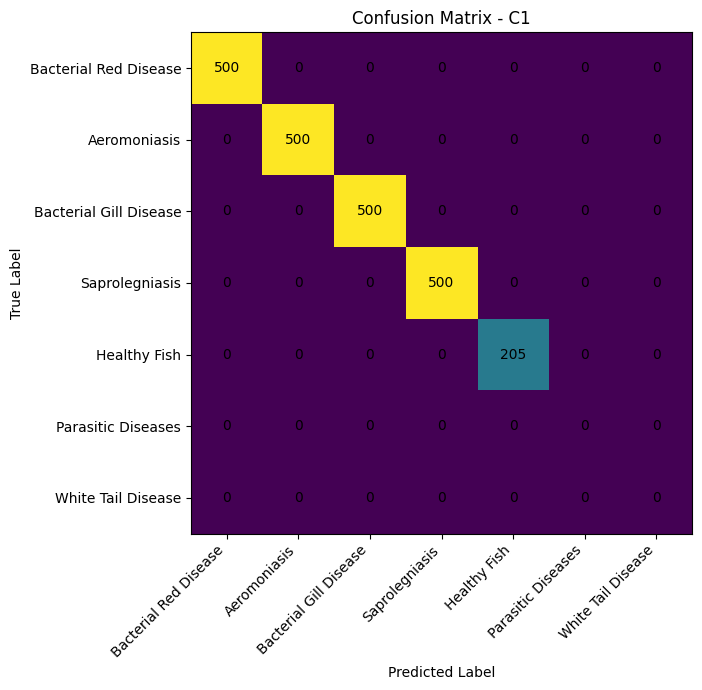

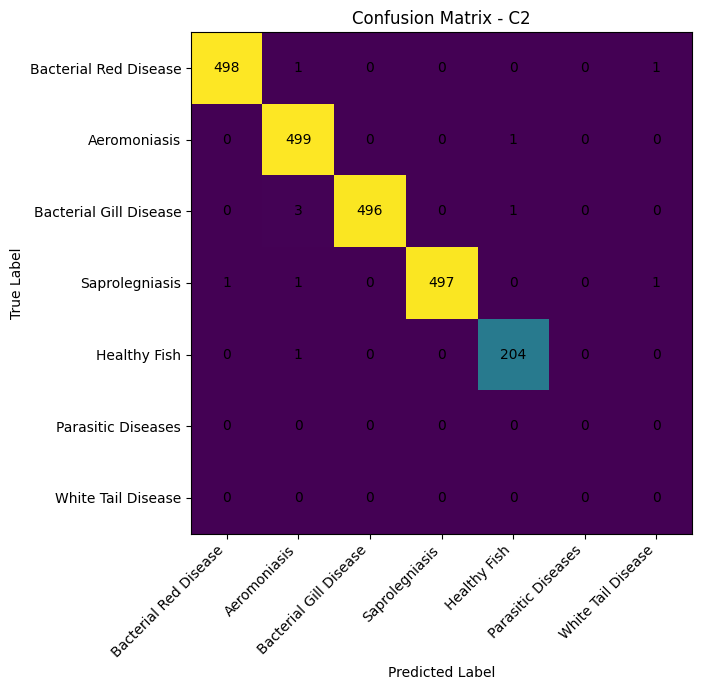

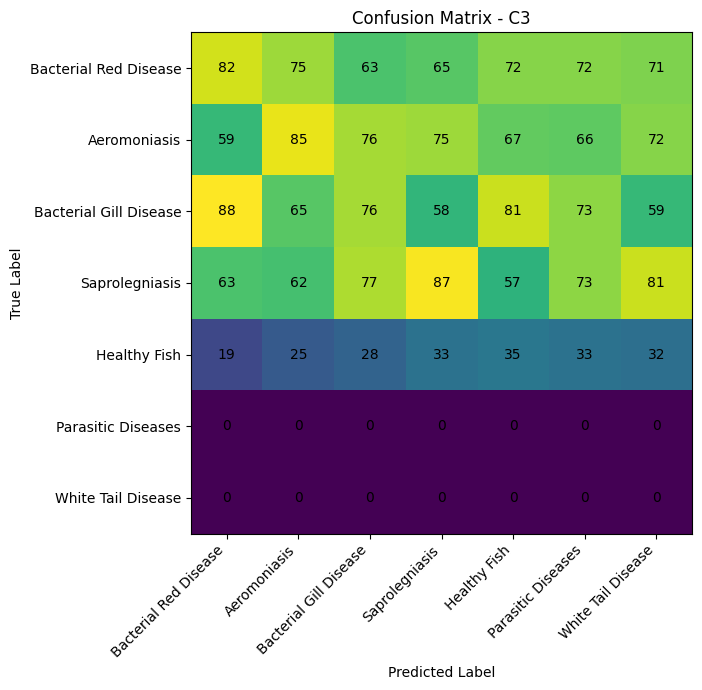

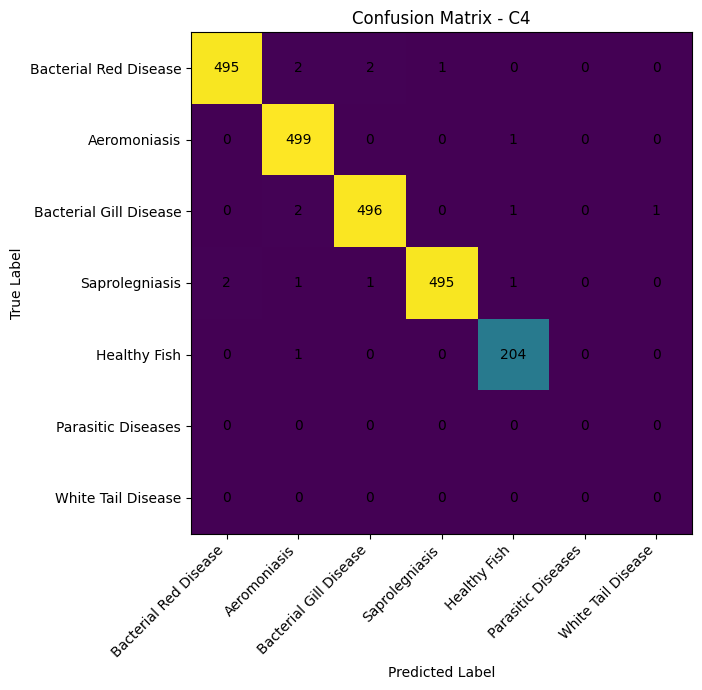

In [ ]:
for cfg, df_cfg in config_tables.items():
    cm = confusion_matrix(df_cfg["true_label"], df_cfg["pred_label"], labels=DISEASE_CLASSES)
    plot_confusion(cm, DISEASE_CLASSES, title=f"Confusion Matrix - {cfg}")

In [ ]:
summary_path = OUTPUT_DIR / "fusion_summary_metrics.csv"
table2_path = OUTPUT_DIR / "table2_ablation_summary.csv"
per_class_path = OUTPUT_DIR / "fusion_per_class_metrics.csv"
mcnemar_path = OUTPUT_DIR / "mcnemar_c4_vs_c1.csv"
weights_path = OUTPUT_DIR / "fusion_weights.csv"

c1_path = OUTPUT_DIR / "c1_image_only_predictions.csv"
c2_path = OUTPUT_DIR / "c2_image_text_predictions.csv"
c3_path = OUTPUT_DIR / "c3_image_sensor_predictions.csv"
c4_path = OUTPUT_DIR / "c4_full_triple_modal_predictions.csv"

summary_df.to_csv(summary_path, index=False)
table2_df.to_csv(table2_path, index=False)
per_class_df.to_csv(per_class_path, index=False)
mcnemar_df.to_csv(mcnemar_path, index=False)
weights_df.to_csv(weights_path, index=False)

c1_df.to_csv(c1_path, index=False)
c2_df.to_csv(c2_path, index=False)
c3_df.to_csv(c3_path, index=False)
c4_df.to_csv(c4_path, index=False)

print("Saved files:")
print(summary_path)
print(table2_path)
print(per_class_path)
print(mcnemar_path)
print(weights_path)
print(c1_path)
print(c2_path)
print(c3_path)
print(c4_path)

Saved files:
/content/drive/MyDrive/aquasense/notebook5_outputs/fusion_summary_metrics.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/table2_ablation_summary.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/fusion_per_class_metrics.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/mcnemar_c4_vs_c1.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/fusion_weights.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/c1_image_only_predictions.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/c2_image_text_predictions.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/c3_image_sensor_predictions.csv
/content/drive/MyDrive/aquasense/notebook5_outputs/c4_full_triple_modal_predictions.csv


In [ ]:
print("===== FUSION RESULTS SUMMARY =====")
display(table2_df)

print("\n===== MCNEMAR TEST: C4 vs C1 =====")
display(mcnemar_df)

print("\n===== FUSION WEIGHTS =====")
display(weights_df)

===== FUSION RESULTS SUMMARY =====


,config,modalities,accuracy,macro_f1,weighted_f1,delta_vs_c1
0,C1,Image only,1.000000,1.000000,1.000000,0.0000
1,C2,Image + Text,0.995011,0.829285,0.995468,-0.1707
2,C3,Image + Sensor,0.165533,0.135008,0.196184,-0.8650
3,C4,Image + Text + Sensor,0.992744,0.827212,0.992971,-0.1728



===== MCNEMAR TEST: C4 vs C1 =====


,b_c1_correct_c4_wrong,c_c1_wrong_c4_correct,mcnemar_statistic,p_value
0,16,0,14.0625,0.000177



===== FUSION WEIGHTS =====


,modality,macro_f1,weight
0,cnn,0.880000,0.318748
1,text,0.980092,0.355003
2,sensor,0.900708,0.326249
